In [1]:
import pandas as pd
from pathlib import Path
import pyarrow as pa  # not yet needed, might need it later
import pyarrow.parquet as pq
import pyarrow.compute as pc  # not yet needed, might need it later.
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

Import the metadata container

In [2]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')

In [3]:
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'num_days_actual_records'],
      dtype='str')

# First Group -- just locations of all sites, by Type

In [4]:
system_locs = systems_cleaned[[
    'system_id', 'latitude', 'longitude', 'is_prize_data',
    'is_lake_parquet_data', 'is_lake_csv_data'
]].drop_duplicates()

In [5]:
system_locs = system_locs[
    system_locs['is_prize_data']
    | system_locs['is_lake_parquet_data']
    | system_locs['is_lake_csv_data']
]

In [6]:
def locs_type(row):
    if row['is_prize_data']:
        return 'prize'
    elif row['is_lake_parquet_data']:
        return 'parquet'
    elif row['is_lake_csv_data']:
        return 'csv'
    else:
        return 'No data'

In [7]:
system_locs['system_type'] = system_locs.apply(locs_type, axis=1)

Following example from https://plotly.com/python/scatter-plots-on-maps/

In [8]:
fig = px.scatter_geo(
    data_frame = system_locs,
    lat = 'latitude',
    lon = 'longitude',
    color='system_type'
)

fig.update_layout(
        title = 'Locations of PVDAQ data sites',
        # comment or un-comment to get global vs. USA
        # geo_scope='usa',
    )
fig.write_html('../../../results/eda/globemap.html')
fig.show()

c:\Users\ch83b\anaconda3\envs\erdos_ds_environment\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [9]:
fig = px.scatter_geo(
    data_frame = system_locs,
    lat = 'latitude',
    lon = 'longitude',
    color='system_type'
)

fig.update_layout(
        title = 'Locations of PVDAQ data sites',
        geo_scope='usa',
    )
fig.write_image('../../../results/eda/usamap.png')
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


(We defer exploration of the non-US site to the postscript below.)

Let's do the non-CSV sites.

In [ ]:
system_locs_not_csv = system_locs[
    system_locs['is_prize_data']
    | system_locs['is_lake_parquet_data']
]

In [ ]:
fig = px.scatter_geo(
    data_frame = system_locs_not_csv,
    lat = 'latitude',
    lon = 'longitude',
    color='system_type'
)

fig.update_layout(
        title = 'Locations of PVDAQ data sites',
        geo_scope='usa',
    )
plt.savefig('../../results/eda/usamap_nocsv.png')
fig.show()

<Figure size 640x480 with 0 Axes>

## Group 2: Let's take all sites with at least 4 features and talk about their characteristics.

In [ ]:
def has_four_features(row):
    running_total = 0
    for col in ['has_temperature_data', 'has_current_data', 
                'has_voltage_data', 'has_power_data', 'has_irradiance_data']:
        running_total += int(row[col])
    return running_total >= 4  # a boolean


systems_cleaned['four_features'] = systems_cleaned.apply(has_four_features, axis=1)
systems_enough_features = systems_cleaned[systems_cleaned['four_features']]

In [ ]:
systems_enough_features.shape

(297, 42)

In [ ]:
fig = px.scatter_geo(
    data_frame = systems_enough_features,
    lat = 'latitude',
    lon = 'longitude',
    color='first_year'
)

fig.update_layout(
        title = 'Rankings of Rich-Data Sites by Starting Year',
        geo_scope='usa',
    )
plt.savefig('../../results/eda/starting_year_map.png')
fig.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
fig = px.scatter_geo(
    data_frame = systems_enough_features,
    lat = 'latitude',
    lon = 'longitude',
    color = 'years'
)

fig.update_layout(
        title = 'Time Durations of Data for High-Quality Facilities',
        geo_scope='usa',
    )
fig.show()

Hard to read, so let's make a histogram.

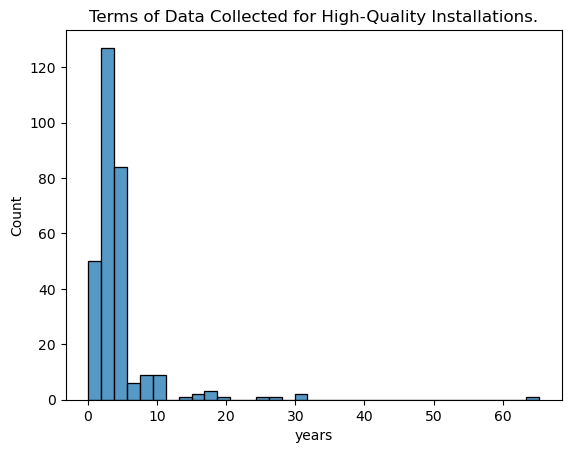

In [ ]:
sns.histplot(
    data = systems_enough_features,
    x = 'years',
)
plt.title('Terms of Data Collected for High-Quality Installations.')
plt.show()

The metadata also lists dc_capacity_kW

In [ ]:
fig = px.scatter_geo(
    data_frame = systems_enough_features,
    lat = 'latitude',
    lon = 'longitude',
    color = 'dc_capacity_kW',
)

fig.update_layout(
        title = 'Power Outputs for High-Quality Facilities',
        geo_scope='usa',
    )
fig.show()

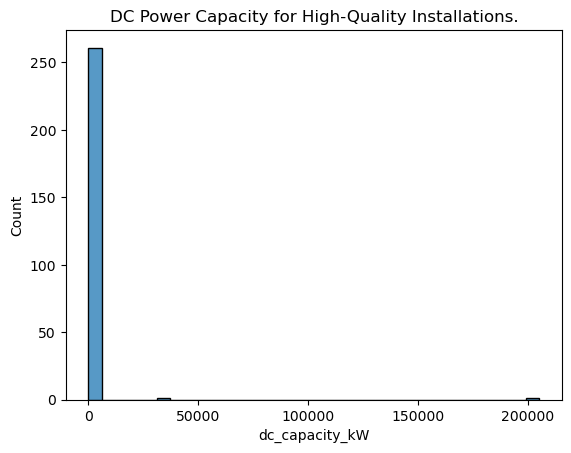

In [ ]:
sns.histplot(
    data = systems_enough_features,
    x = 'dc_capacity_kW',
)
plt.title('DC Power Capacity for High-Quality Installations.')
plt.show()

In [ ]:
fig = px.scatter_geo(
    data_frame = systems_enough_features,
    lat = 'latitude',
    lon = 'longitude',
    color = 'kg_climate',
)

fig.update_layout(
        title = 'Köppen–Geiger climate classification for High-Quality Facilities',
        geo_scope='usa',
    )
fig.show()

## Material Type

In [ ]:
fig = px.scatter_geo(
    data_frame = systems_enough_features,
    lat = 'latitude',
    lon = 'longitude',
    color = 'simplified_type',
)

fig.update_layout(
        title = 'Simplified Material Types for High-Quality Facilities',
        geo_scope='usa',
    )
fig.show()

A decent mix!

# Postscript: What about that non-USA site?

In [ ]:
system_non_us = system_locs[
    system_locs['longitude'] > -40
]

In [ ]:
system_non_us.head()

,system_id,latitude,longitude,is_prize_data,is_lake_parquet_data,is_lake_csv_data,system_type
143,1416,35.7793,78.63411,False,True,True,parquet


In [ ]:
metrics_dir = Path('./data/raw/parquet-metrics/')
# Note: We generally give a directory, rather than an individual file, to the next step.
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()

In [ ]:
metrics_df[
    metrics_df['sensor_name'].str.contains('humid')
]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
163,1203,2892,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__2892
303,1229,883,relative_humidity,Humidity,-,-,1.0,0.0,,avg,NaN,NaN,,relative_humidity__883
310,1230,892,relative_humidity,Humidity,-,-,1.0,0.0,,NaN,NaN,NaN,,relative_humidity__892
320,1239,3017,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__3017
455,1276,3027,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__3027
470,1277,3042,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__3042
493,1278,3057,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__3057
1329,34,2687,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__2687
1344,35,2705,relative_humidity,Humidity,%,%,1.0,0.0,,avg,NaN,NaN,,relative_humidity__2705


In [ ]:
intl_site = metrics_df[metrics_df['system_id'] == 1416]

In [ ]:
intl_site

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1107,1416,4742,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__4742
1108,1416,4762,ac_current_phA,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current_pha__4762
1109,1416,4763,ac_current_phB,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current_phb__4763
1110,1416,4764,ac_current_phC,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current_phc__4764
1111,1416,4749,ac_current,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current__4749
1112,1416,4746,power_factor,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor__4746
1113,1416,4753,power_factor_phA,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_pha__4753
1114,1416,4754,power_factor_phB,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_phb__4754
1115,1416,4755,power_factor_phC,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_phc__4755
1116,1416,4745,apparent_power_kVA,AC other,kVA,VA,1000.0,0.0,,avg,NaN,NaN,,apparent_power_kva__4745


In [ ]:
data_asia_dir = Path('../data_ds_project/systems/parquet/1416/')
data_asia_pq = pq.ParquetDataset(data_asia_dir,
                                 filters=[
                                     ('metric_id', 'in', [4734, 4735, 4744, 4745])
                                 ])
data_asia_df = data_asia_pq.read().to_pandas()

In [ ]:
data_asia_df.loc[30000:30019, 'measured_on']

30000   2015-11-06 02:15:55
30001   2015-11-06 02:16:00
30002   2015-11-06 02:16:05
30003   2015-11-06 02:16:10
30004   2015-11-06 02:16:15
30005   2015-11-06 02:16:20
30006   2015-11-06 02:16:25
30007   2015-11-06 02:16:30
30008   2015-11-06 02:16:35
30009   2015-11-06 02:16:40
30010   2015-11-06 02:16:45
30011   2015-11-06 02:16:50
30012   2015-11-06 02:16:55
30013   2015-11-06 02:17:00
30014   2015-11-06 02:17:05
30015   2015-11-06 02:17:10
30016   2015-11-06 02:17:15
30017   2015-11-06 02:17:20
30018   2015-11-06 02:17:25
30019   2015-11-06 02:17:30
Name: measured_on, dtype: datetime64[ns]

In [ ]:
data_asia_df['measured_on'] = pd.to_datetime(
    data_asia_df['measured_on'], format = "%Y-%m-%d %H:%M:%S"
).astype('datetime64[s]')

In [ ]:
data_asia_df['measured_on'].max()

Timestamp('2018-03-26 22:50:35')